In [ ]:
import os

datapath = os.path.join("datasets", "lifesat", "")

In [38]:
# To plot pretty figures directly within Jupyter
%matplotlib inline
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [ ]:
# Download the data
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
os.makedirs(datapath, exist_ok=True)
for filename in ("oecd_bli_2015.csv", "gdp_per_capita.csv"):
    print("Downloading", filename)
    url = DOWNLOAD_ROOT + "datasets/lifesat/" + filename
    urllib.request.urlretrieve(url, datapath + filename)
print("Download complete")

Download complete


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Load the data
oecd_bli = pd.read_csv(datapath + "oecd_bli_2015.csv", thousands=",")
gdp_per_capita = pd.read_csv(
    datapath + "gdp_per_capita.csv",
    thousands=",",
    delimiter="\t",
    encoding="latin1",
    na_values="n/a",
)

In [41]:
from IPython.display import display

display(oecd_bli.head())
display(gdp_per_capita.head())

,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
0,AUS,Australia,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.1,E,Estimated value
1,AUT,Austria,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.0,NaN,NaN
2,BEL,Belgium,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,2.0,NaN,NaN
3,CAN,Canada,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.2,NaN,NaN
4,CZE,Czech Republic,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.9,NaN,NaN


,Country,Subject Descriptor,Units,Scale,Country/Series-specific Notes,2015,Estimates Start After
0,Afghanistan,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",599.994,2013.0
1,Albania,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",3995.383,2010.0
2,Algeria,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4318.135,2014.0
3,Angola,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",4100.315,2014.0
4,Antigua and Barbuda,"Gross domestic product per capita, current prices",U.S. dollars,Units,"See notes for: Gross domestic product, curren...",14414.302,2011.0


In [ ]:
# function to merger two tables oecd_bli and gdp_per_capita cleanly
def prepare_country_stats(oecd_bli, gdp_per_capita):
    oecd_bli = oecd_bli[oecd_bli["INEQUALITY"] == "TOT"]
    oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
    gdp_per_capita.rename(columns={"2015": "GDP per capita"}, inplace=True)
    if "Country" in gdp_per_capita.columns:
        gdp_per_capita.set_index("Country", inplace=True)
    full_country_stats = oecd_bli.join(gdp_per_capita)
    full_country_stats.sort_values(by="GDP per capita", inplace=True)
    remove_indices = [0, 1, 6, 8, 33, 34, 35]
    keep_indices = list(set(range(36)) - set(remove_indices))
    return full_country_stats[["GDP per capita", "Life satisfaction"]].iloc[
        keep_indices
    ]

### Model-based vs Instance-based Learning

**Linear Regression (Model-based learning)**

- Linear regression learns a mathematical relationship between variables by fitting a line to the training data.  
  During training, the algorithm estimates parameters (slope and intercept) that minimize prediction error.

Example model:
ŷ = w₀ + w₁x

After training, predictions are made using only the learned parameters, not the original dataset.  
This is why linear regression is called a **model-based algorithm**.


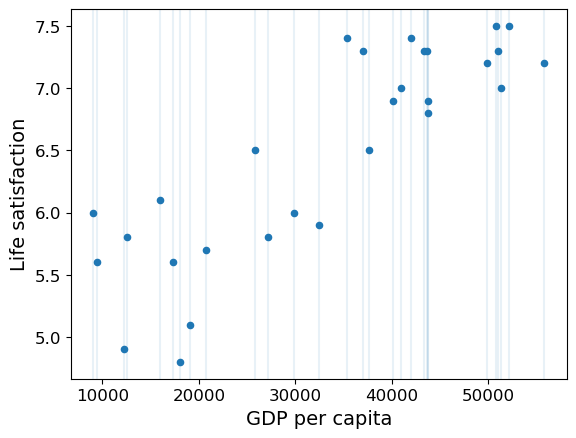

[[5.96242338]]


In [ ]:
import sklearn.linear_model

# Prepare the data
country_stats = prepare_country_stats(oecd_bli, gdp_per_capita)
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

# Visualize the data
country_stats.plot(kind="scatter", x="GDP per capita", y="Life satisfaction")
for x in country_stats["GDP per capita"]:
    plt.axvline(x=x, alpha=0.1)
# plt.axvline(x=22587, color = 'red')
plt.show()

# Select a linear model
model = sklearn.linear_model.LinearRegression()

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
X_new = np.array([[22587]])
print(model.predict(X_new))

**k-Nearest Neighbors (Instance-based learning)**  
KNN does not learn an explicit model. Instead, it stores the training data and makes predictions by finding the **k closest data points** to a new input and averaging their target values (for regression).

Prediction steps:

1. Compute distance between the new point and all training points
2. Select the k nearest neighbors
3. Average their target values

Because it relies directly on stored examples rather than a learned equation, KNN is called an **instance-based (lazy learning) algorithm**.


In [65]:
import sklearn.neighbors

# Prepare the data
X = np.c_[country_stats["GDP per capita"]]
y = np.c_[country_stats["Life satisfaction"]]

# Select the model
model = sklearn.neighbors.KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X, y)

X_new = np.array([[22587]])
print(model.predict(X_new))

[[5.76666667]]
